---
  title: "Aula 2"
  author: Mauro Alixandrini
  date: 2026-09-09
  categories: [GeoAI, technology]
  image: ambiente.jpg
---

In [ ]:
# Instalação do Miniconda
#baixar o miniconda 
curl https://repo.anaconda.com/miniconda/Miniconda3-latest-Windows-x86_64.exe -o .\miniconda.exe

#instalar
start /wait "" .\miniconda.exe /S

# excluir o executavel 
del .\miniconda.exe


# Testar no anaconda prompt

conda --version
python --version


# Configuração do Ambiente

In [1]:
import sys
import importlib
print(f"Python version: {sys.version}\n")
# Check core packages
packages = {
    "torch": "PyTorch",
    "torchvision": "TorchVision",
    "geoai": "GeoAI",
    "leafmap": "Leafmap",
    "geopandas": "GeoPandas",
    "rasterio": "Rasterio",
    "samgeo": "Segment-Geospatial",
    "torchgeo": "TorchGeo",
}
for module_name, display_name in packages.items():
    try:
        mod = importlib.import_module(module_name)
        version = getattr(mod, "__version__", "installed")
        print(f"  {display_name}: {version}")
    except ImportError:
        print(f"  {display_name}: NOT FOUND")
        
import torch
print(f"\nCUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
else:
    print("Running in CPU-only mode.")

Python version: 3.13.15 | packaged by Anaconda, Inc. | (main, Aug 14 2026, 17:17:48) [MSC v.1942 64 bit (AMD64)]

  PyTorch: 2.13.0
  TorchVision: 0.28.0
  GeoAI: 0.42.0


c:\Users\mauro\.conda\envs\geoai\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


  Leafmap: 0.63.0
  GeoPandas: 1.1.4
  Rasterio: 1.4.4
  Segment-Geospatial: NOT FOUND
  TorchGeo: 0.10.0

CUDA available: True
GPU device: NVIDIA RTX 2000 Ada Generation Laptop GPU
CUDA version: 12.8


In [2]:
import leafmap
m = leafmap.Map(center=[40, -100], zoom=4)
m

Map(center=[40, -100], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_t…

# Dados Raster
## O Que São Dados Raster?
Dados raster representam o mundo como uma grade regular de células, comumente chamadas de pixels.
Cada pixel armazena um ou mais valores numéricos que descrevem uma propriedade naquela localização, como reflectância de superfície, elevação ou temperatura. A grade tem uma resolução espacial fixa (a área de terreno representada por cada pixel) e pode conter múltiplas bandas, onde cada banda captura uma medição diferente.


Pense  em  uma  fotografi a  digital.  Ela  é  uma  grade  de  pixels  com  três  bandas  (vermelho,  verde,  azul).
Imagens de satélite funcionam da mesma forma, exceto com mais bandas, coordenadas georreferenciadas
e pixels que podem abranger metros ou até quilômetros no terreno.

## Lendo Dados Raster com Python

A biblioteca  rasterio  é a ferramenta padrão para leitura de dados raster em Python. Ela fornece uma
interface limpa para o GDAL, a Geospatial Data Abstraction Library subjacente.

In [3]:
import geoai
import rasterio
raster_url = "https://data.source.coop/opengeos/geoai/naip-train.tif"
raster_path = geoai.download_file(raster_url)
with rasterio.open(raster_path) as src:
    print(f"Shape: {src.height} x {src.width}")
    print(f"Bands: {src.count}")
    print(f"CRS: {src.crs}")
    print(f"Resolution: {src.res}")
    band1 = src.read(1)  # Read the first band as a NumPy array
    print(f"Band 1 dtype: {band1.dtype}")

Shape: 1126 x 2503
Bands: 4
CRS: PROJCS["NAD83 / UTM zone 11N",GEOGCS["NAD83",DATUM["North American Datum 1983",SPHEROID["GRS 1980",6378137,298.257222101004]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Resolution: (0.5999999999999953, 0.5999999999996691)
Band 1 dtype: uint8


Alternativamente,  você  pode  usar  a  biblioteca  geoai   para  imprimir  metadados  do  raster  e  exibir  a
imagem em uma linha de código:

===== RASTER INFORMATION: naip-train.tif =====
Driver: GTiff
Dimensions: 2503 x 1126 pixels
Number of bands: 4
Data type: uint8
Coordinate Reference System: PROJCS["NAD83 / UTM zone 11N",GEOGCS["NAD83",DATUM["North American Datum 1983",SPHEROID["GRS 1980",6378137,298.257222101004]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Georeferenced Bounds: BoundingBox(left=454780.8, bottom=5277567.0, right=456282.6, top=5278242.6)
Pixel Resolution: 0.6, 0.6
NoData Value: None
----- Band Statistics -----
Band 1:
  Min: 12.00
  Max: 251.00
  Mean: 150.67
  Std Dev: 48.02
Band 2:
  Min: 49.00
  Max: 251.00
  Mean: 141.92
  Std Dev: 43.47
Band 3:
  Min: 53.00
  Max: 251.00
  Mean: 

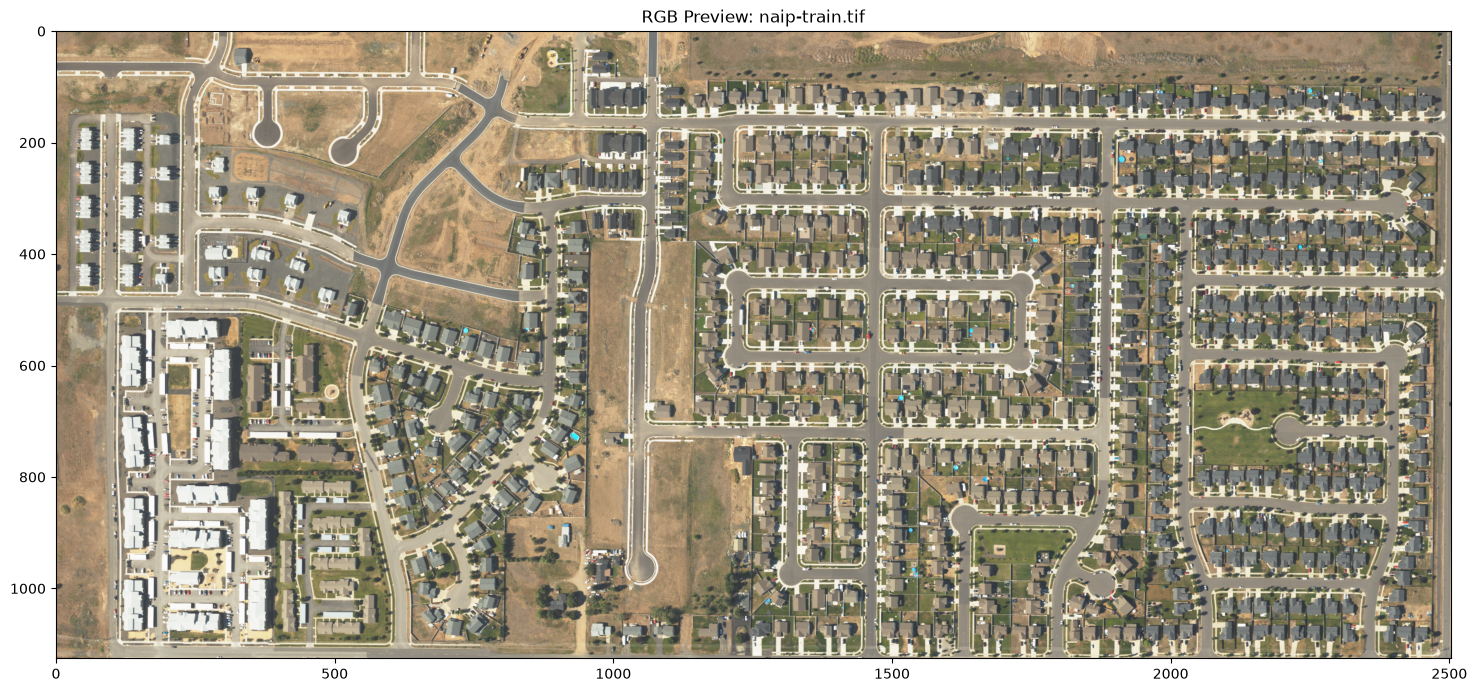

In [4]:
geoai.print_raster_info(raster_path, figsize=(18, 10))

Ler uma janela específica (subconjunto) de um raster grande é simples e frequentemente essencial ao
trabalhar com cenas grandes:

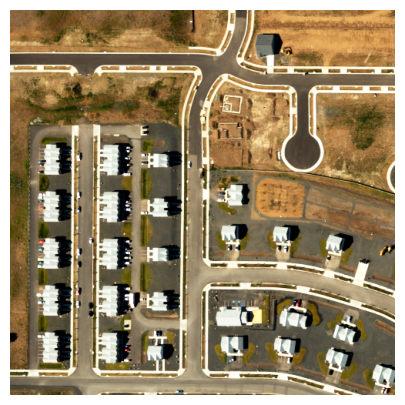

In [5]:
clip_raster_path = "naip_clip.tif"
geoai.clip_raster_by_bbox(
    raster_path,
    clip_raster_path,
    bbox=(0, 0, 500, 500),
    bands=[1, 2, 3],
    bbox_type="pixel",
)
geoai.view_image(clip_raster_path)

# Dados Vetoriais
## O Que São Dados Vetoriais?
Enquanto dados raster se destacam na representação de fenômenos contínuos como reflectância, elevação e temperatura, muitas feições geográficas são melhor descritas como objetos discretos com limites bem definidos. Uma edificação tem bordas. Uma estrada tem uma linha central. Um lago tem uma margem.


Dados vetoriais capturam essas feições usando primitivos geométricos, tornando-os o formato natural para representar estruturas construídas pelo homem, limites administrativos e muitos rótulos de anotação em fluxos de trabalho de GeoAI.

## Lendo Dados Vetoriais com Python

In [ ]:
############### Aqui para quem tem problemas com PROJ/GDAL no Windows ###############
import os
import sys

# 1. Limpa qualquer variável de PROJ/GDAL global da máquina que cause interferência
for var in ["PROJ_LIB", "PROJ_DATA", "GDAL_DATA"]:
    if var in os.environ:
        del os.environ[var]

# 2. Aponta para os diretórios corretos do ambiente Conda 'geoai'
conda_prefix = sys.prefix
proj_dir = os.path.join(conda_prefix, "Library", "share", "proj")
gdal_dir = os.path.join(conda_prefix, "Library", "share", "gdal")

os.environ["PROJ_DATA"] = proj_dir
os.environ["GDAL_DATA"] = gdal_dir

# 3. Força o pyproj a inicializar o contexto antes de qualquer outra lib geoespacial
import pyproj
pyproj.datadir.set_data_dir(proj_dir)

# 4. Importa as demais bibliotecas
import geoai
import geopandas as gpd

print("PROJ ativo em:", pyproj.datadir.get_data_dir())

PROJ ativo em: c:\Users\mauro\.conda\envs\geoai\Library\share\proj


In [9]:
import geopandas as gpd
vector_url = "https://data.source.coop/opengeos/geoai/naip-train-buildings.geojson"
vector_path = geoai.download_file(vector_url)
gdf = gpd.read_file(vector_path)
print(f"Features: {len(gdf)}")
print(f"CRS: {gdf.crs}")
gdf.head()

Features: 735
CRS: EPSG:4326


,id,height,class,geometry
0,1,0,building,"POLYGON ((-117.60111 47.6502, -117.60109 47.65..."
1,2,0,building,"POLYGON ((-117.6008 47.65042, -117.6008 47.650..."
2,3,0,building,"POLYGON ((-117.60049 47.65046, -117.60049 47.6..."
3,4,0,building,"POLYGON ((-117.60048 47.65021, -117.60035 47.6..."
4,5,0,building,"POLYGON ((-117.60012 47.65046, -117.60012 47.6..."


A biblioteca  geoai  também fornece uma alternativa de uma linha que imprime metadados vetoriais e
exibe os dados:

===== VECTOR INFORMATION: naip-train-buildings.geojson =====
Driver: GEOJSON
Feature count: 735
Geometry types: {'Polygon': 735}
Coordinate Reference System: EPSG:4326
Bounds: [-117.6017984, 47.65016239407519, -117.58246913360121, 47.655846]
Number of attributes: 3
Attribute names: id, height, class
----- Attribute Statistics -----
Attribute: id
  min: 1
  max: 735
  mean: 368.0000
  std: 212.3205
  null_count: 0
Attribute: height
  min: 0
  max: 0
  mean: 0.0000
  std: 0.0000
  null_count: 0


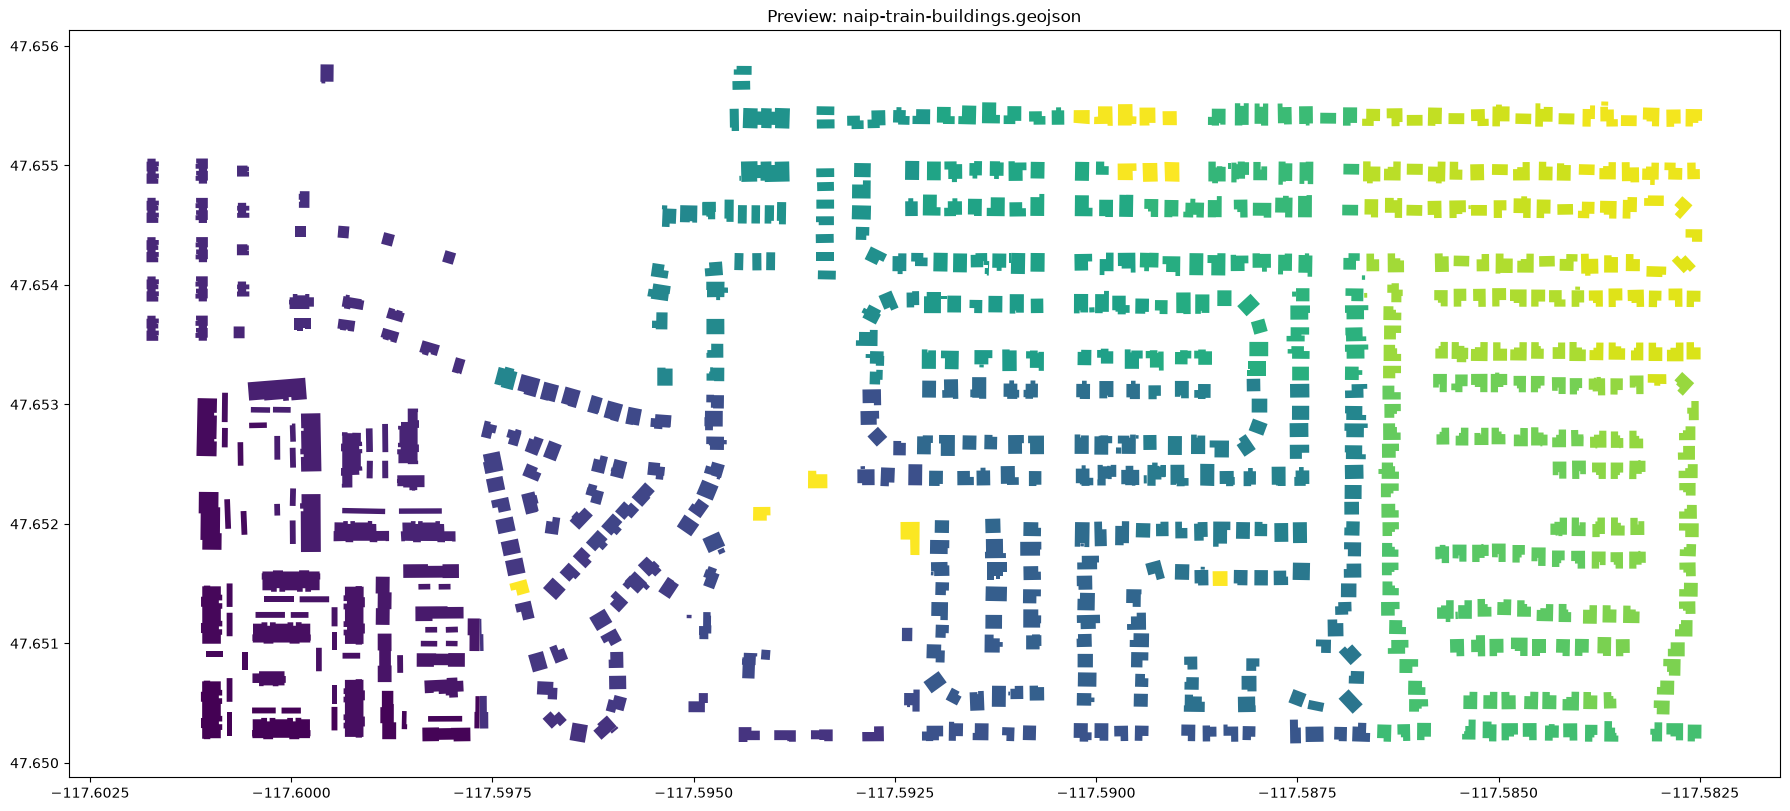

In [10]:
geoai.print_vector_info(vector_path, figsize=(18, 10))

Para visualizar os dados vetoriais em um mapa base, você pode usar a função  geoai.view_vector()
com  basemap=True . Ela busca tiles do OpenStreetMap e os adiciona como camada de fundo.

<Axes: >

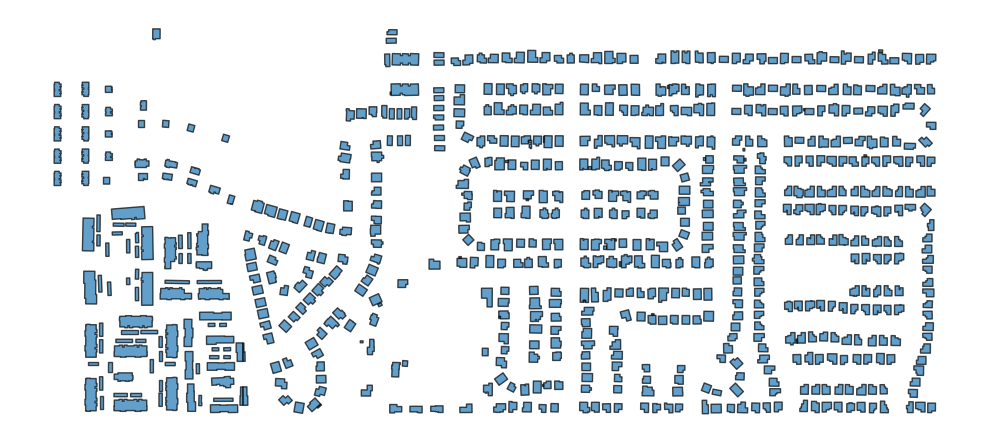

In [11]:
geoai.view_vector(vector_path, basemap=True)

Para visualizar os dados vetoriais sobre um raster, você pode usar a função  geoai.view_vector()  com
o parâmetro  raster_path  defi nido como o arquivo raster.

<Axes: >

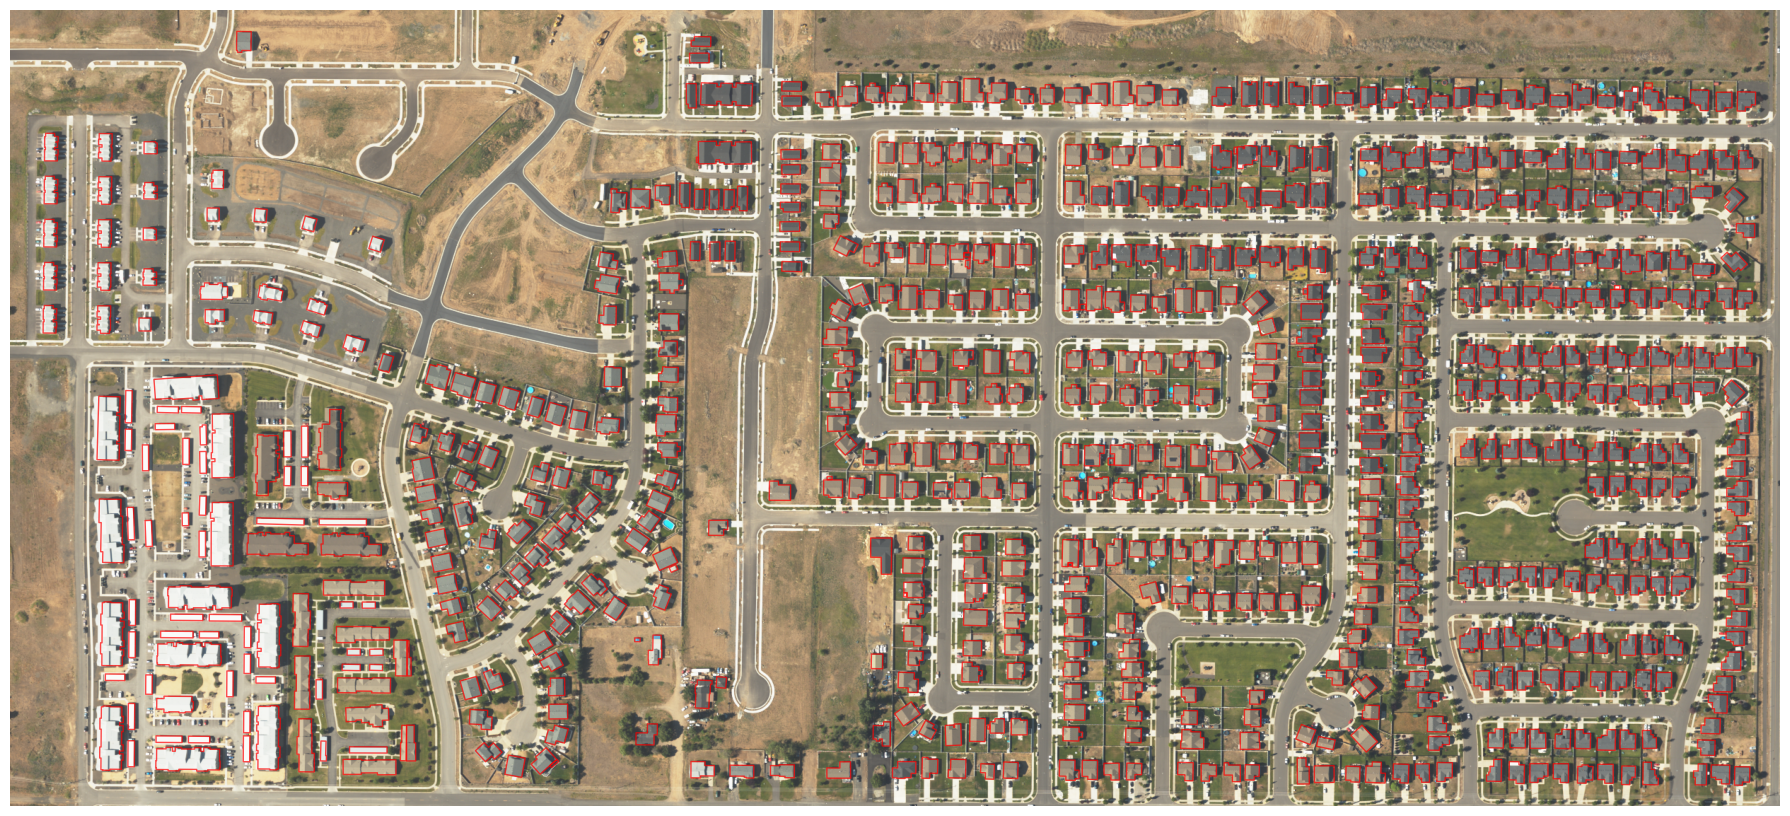

In [12]:
geoai.view_vector(
    vector_path,
    raster_path=raster_path,
    outline_only=True,
    edge_color="red",
    figsize=(18, 10),
)

## Reprojeção

A reprojeção converte dados de um CRS para outro. Para reprojetar dados raster, você pode usar a função  leafmap.reproject() . Escolha o método de reamostragem cuidadosamente: reamostragem bilinear ou cúbica é apropriada para imagens contínuas, enquanto vizinho mais próximo é mais seguro para rasters categóricos como rótulos de cobertura do solo
ou máscaras de segmentação.

In [13]:
import leafmap
leafmap.reproject(
    image=raster_path,
    output="naip_reprojected.tif",
    dst_crs="EPSG:3857",
    resampling="bilinear",
)

Reading input: c:\Users\mauro\OneDrive\Documentos\PPEC083 - Sensoriamento Remoto\naip_reprojected.tif

Adding overviews...
Updating dataset tags...
Writing output to: c:\Users\mauro\OneDrive\Documentos\PPEC083 - Sensoriamento Remoto\naip_reprojected.tif


## Tiling de Imagens 

In [14]:
leafmap.split_raster(
    raster_path,
    out_dir="naip_tiles",
    tile_size=512,
    overlap=128,
)